# Inmate Processing Time Prediction
### Predicting Jail Release Duration Using Machine Learning

**Author:** Esther  
**Dataset:** Inmate Booking Records (200 records, 4 Kentucky Counties, 2024)  
**Goal:** Build a regression model that predicts how many days an inmate will be held before release, based on features known at booking time.

---

## Project Structure
1. [Data Loading & Inspection](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Feature Engineering](#3)
4. [Model Training & Evaluation](#4)
5. [Model Comparison](#5)
6. [Feature Importance](#6)
7. [Conclusions & Key Findings](#7)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


---
<a id='1'></a>
## 1. Data Loading & Inspection

In [2]:
df = pd.read_excel('inmate_dashboard.xlsx', sheet_name='Raw Data')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes)
print()
df.head(10)


Shape: 200 rows × 6 columns

Column types:
booking_time        datetime64[ns]
court_delay_days             int64
charge_type                 object
county                      object
holds                        int64
release_days                 int64
dtype: object



,booking_time,court_delay_days,charge_type,county,holds,release_days
0,2024-02-21,8,Misdemeanor,Boone,0,17
1,2024-04-02,4,Felony,Fayette,1,11
2,2024-01-15,0,Misdemeanor,Jefferson,1,7
3,2024-03-12,2,Felony,Jefferson,1,8
4,2024-03-01,9,Misdemeanor,Boone,1,17
5,2024-01-21,7,Misdemeanor,Boone,1,11
6,2024-03-23,5,Misdemeanor,Kenton,1,13
7,2024-03-27,7,Misdemeanor,Jefferson,1,11
8,2024-03-15,8,Felony,Kenton,1,16
9,2024-03-15,3,Misdemeanor,Boone,1,12


In [3]:
# Statistical summary
df.describe(include='all').round(2)


,booking_time,court_delay_days,charge_type,county,holds,release_days
count,200,200.00,200,200,200.0,200.00
unique,NaN,NaN,2,4,NaN,NaN
top,NaN,NaN,Misdemeanor,Jefferson,NaN,NaN
freq,NaN,NaN,107,64,NaN,NaN
mean,2024-02-19 00:14:24,4.01,NaN,NaN,0.5,9.12
min,2024-01-01 00:00:00,0.00,NaN,NaN,0.0,1.00
25%,2024-01-25 12:00:00,1.75,NaN,NaN,0.0,6.00
50%,2024-02-20 12:00:00,4.00,NaN,NaN,0.0,9.00
75%,2024-03-15 06:00:00,7.00,NaN,NaN,1.0,12.00
max,2024-04-09 00:00:00,9.00,NaN,NaN,1.0,18.00


In [4]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")


Missing values per column:
booking_time        0
court_delay_days    0
charge_type         0
county              0
holds               0
release_days        0
dtype: int64

Total missing: 0


---
<a id='2'></a>
## 2. Exploratory Data Analysis (EDA)

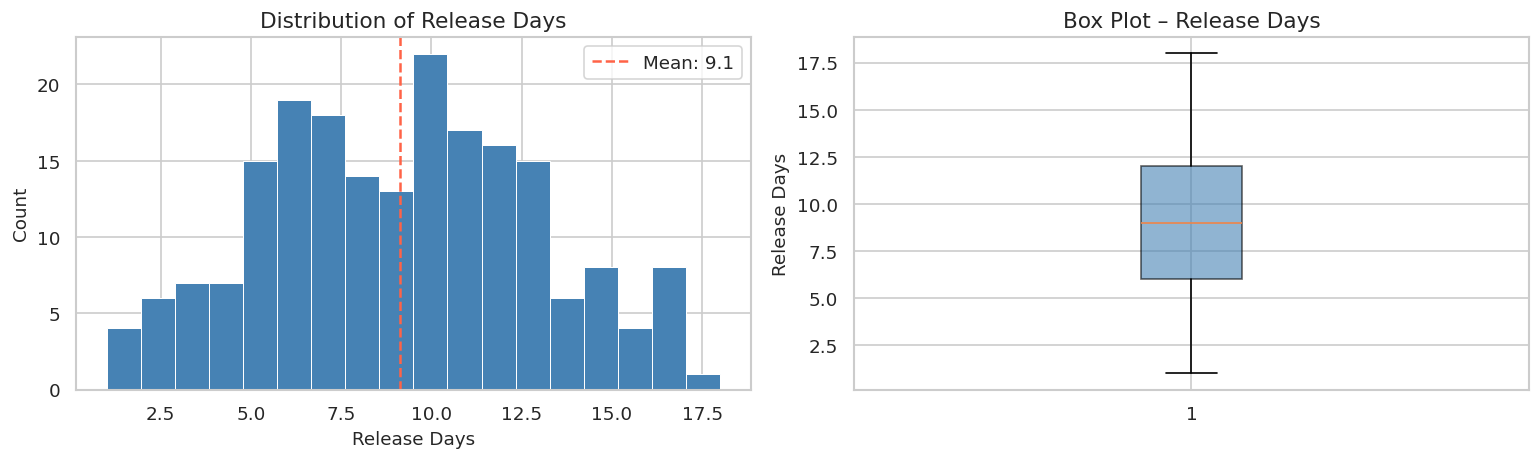

Skewness: 0.073


In [5]:
# ── Distribution of target variable: release_days ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['release_days'], bins=18, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title('Distribution of Release Days')
axes[0].set_xlabel('Release Days')
axes[0].set_ylabel('Count')
axes[0].axvline(df['release_days'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Mean: {df['release_days'].mean():.1f}")
axes[0].legend()

axes[1].boxplot(df['release_days'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot – Release Days')
axes[1].set_ylabel('Release Days')

plt.tight_layout()
plt.savefig('plot_release_distribution.png', bbox_inches='tight')
plt.show()
print(f"Skewness: {df['release_days'].skew():.3f}")


,County,Avg Release Days,Std Dev,Count
0,Boone,10.54,3.91,46
1,Fayette,8.30,4.01,40
2,Jefferson,8.64,3.86,64
3,Kenton,9.10,3.99,50


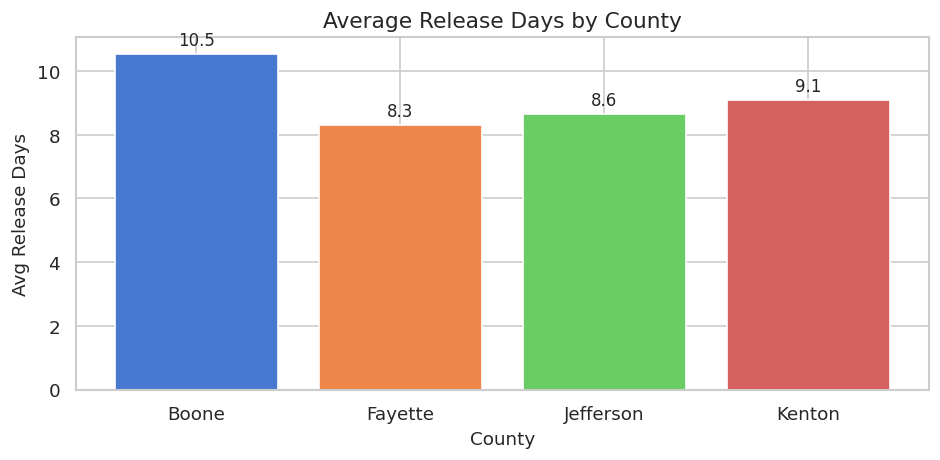

In [6]:
# ── Average release days by county ──
county_avg = df.groupby('county')['release_days'].agg(['mean', 'std', 'count']).round(2).reset_index()
county_avg.columns = ['County', 'Avg Release Days', 'Std Dev', 'Count']
display(county_avg)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(county_avg['County'], county_avg['Avg Release Days'],
              color=sns.color_palette("muted", 4), edgecolor='white')
ax.set_title('Average Release Days by County')
ax.set_ylabel('Avg Release Days')
ax.set_xlabel('County')
for bar, val in zip(bars, county_avg['Avg Release Days']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('plot_county_release.png', bbox_inches='tight')
plt.show()


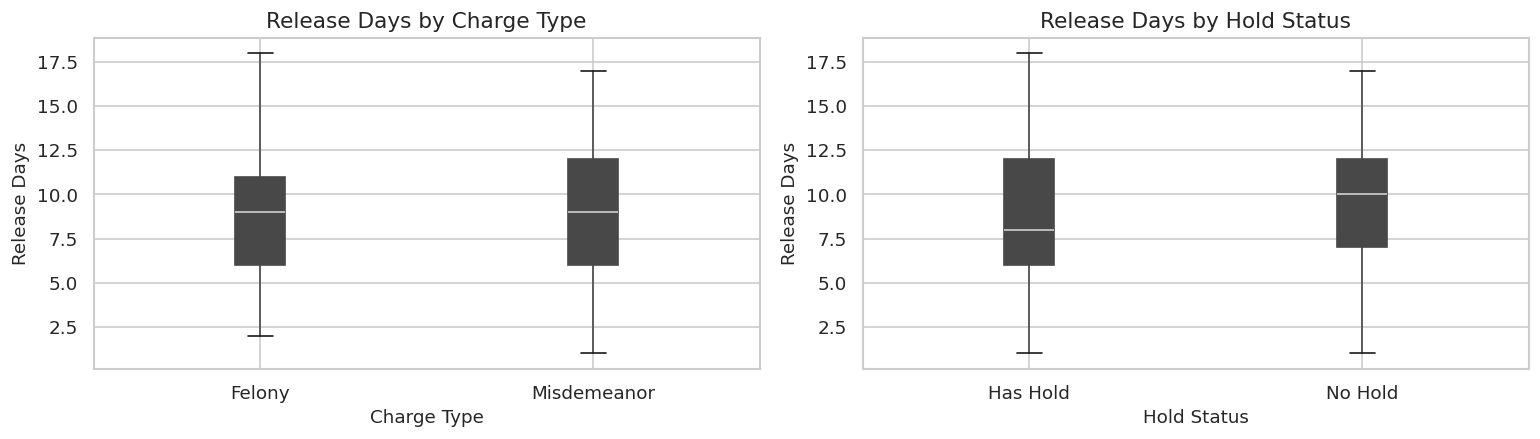

In [7]:
# ── Release days by charge type and hold status ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='release_days', by='charge_type', ax=axes[0], patch_artist=True)
axes[0].set_title('Release Days by Charge Type')
axes[0].set_xlabel('Charge Type')
axes[0].set_ylabel('Release Days')
plt.sca(axes[0])
plt.title('Release Days by Charge Type')

df['hold_label'] = df['holds'].map({0: 'No Hold', 1: 'Has Hold'})
df.boxplot(column='release_days', by='hold_label', ax=axes[1], patch_artist=True)
axes[1].set_title('Release Days by Hold Status')
axes[1].set_xlabel('Hold Status')
axes[1].set_ylabel('Release Days')
plt.sca(axes[1])
plt.title('Release Days by Hold Status')

plt.suptitle('')
plt.tight_layout()
plt.savefig('plot_charge_hold.png', bbox_inches='tight')
plt.show()


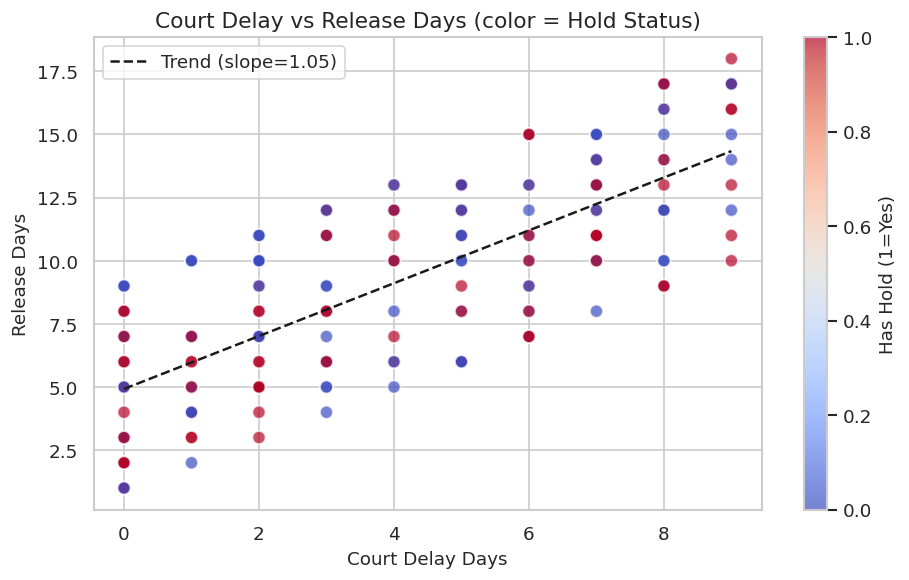

In [8]:
# ── Court delay vs release days scatter ──
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['court_delay_days'], df['release_days'],
                     c=df['holds'], cmap='coolwarm', alpha=0.7, edgecolors='white', s=60)
ax.set_xlabel('Court Delay Days')
ax.set_ylabel('Release Days')
ax.set_title('Court Delay vs Release Days (color = Hold Status)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Has Hold (1=Yes)')

# Trend line
z = np.polyfit(df['court_delay_days'], df['release_days'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['court_delay_days'].min(), df['court_delay_days'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label=f'Trend (slope={z[0]:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('plot_scatter_delay_release.png', bbox_inches='tight')
plt.show()


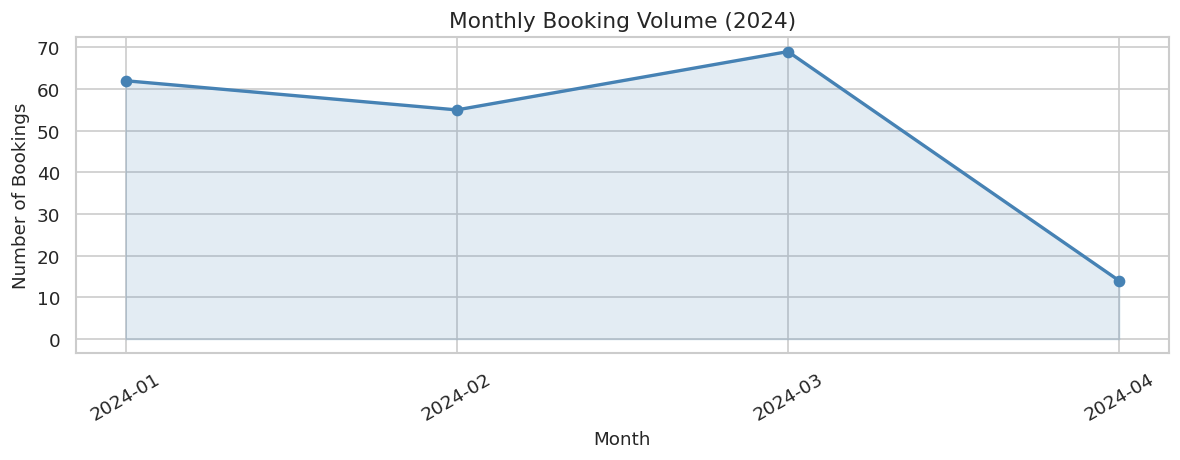

In [9]:
# ── Bookings over time (monthly trend) ──
df['booking_time'] = pd.to_datetime(df['booking_time'])
df['month'] = df['booking_time'].dt.to_period('M')
monthly = df.groupby('month').size().reset_index(name='bookings')
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly['month_str'], monthly['bookings'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['month_str'], monthly['bookings'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Booking Volume (2024)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot_monthly_bookings.png', bbox_inches='tight')
plt.show()


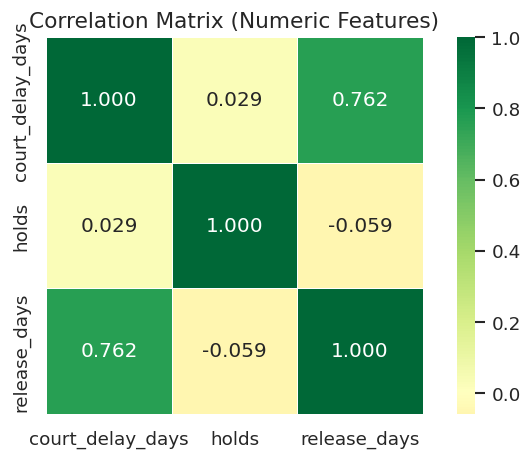

In [10]:
# ── Correlation heatmap ──
numeric_df = df[['court_delay_days', 'holds', 'release_days']].copy()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()


---
<a id='3'></a>
## 3. Feature Engineering

In [11]:
# ── Encode categorical variables ──
df_model = df[['court_delay_days', 'charge_type', 'county', 'holds', 'release_days']].copy()

le_charge = LabelEncoder()
le_county = LabelEncoder()

df_model['charge_type_enc'] = le_charge.fit_transform(df_model['charge_type'])
df_model['county_enc']      = le_county.fit_transform(df_model['county'])

print("Charge type mapping:", dict(zip(le_charge.classes_, le_charge.transform(le_charge.classes_))))
print("County mapping:     ", dict(zip(le_county.classes_, le_county.transform(le_county.classes_))))

# Final feature set
FEATURES = ['court_delay_days', 'holds', 'charge_type_enc', 'county_enc']
TARGET   = 'release_days'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"\nFeature matrix: {X.shape}")
print(f"Target vector:  {y.shape}")
X.describe().round(2)


Charge type mapping: {'Felony': np.int64(0), 'Misdemeanor': np.int64(1)}
County mapping:      {'Boone': np.int64(0), 'Fayette': np.int64(1), 'Jefferson': np.int64(2), 'Kenton': np.int64(3)}

Feature matrix: (200, 4)
Target vector:  (200,)


,court_delay_days,holds,charge_type_enc,county_enc
count,200.00,200.0,200.00,200.00
mean,4.01,0.5,0.54,1.59
std,2.91,0.5,0.50,1.10
min,0.00,0.0,0.00,0.00
25%,1.75,0.0,0.00,1.00
50%,4.00,0.0,1.00,2.00
75%,7.00,1.0,1.00,2.25
max,9.00,1.0,1.00,3.00


In [12]:
# ── Train / test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Scale features (used for linear models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train size: 160 | Test size: 40


---
<a id='4'></a>
## 4. Model Training & Evaluation

We train four models and compare them:
- **Linear Regression** (baseline)
- **Ridge Regression** (regularized linear)
- **Random Forest** (ensemble tree)
- **XGBoost** (gradient boosting)


In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train, predict, and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    
    # 5-fold CV on training set
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    
    return {
        'Model': name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²': round(r2, 3),
        'CV R² (mean)': round(cv_scores.mean(), 3),
        'CV R² (std)':  round(cv_scores.std(), 3),
        '_model': model,
        '_preds': preds
    }

results = []

# 1. Linear Regression
results.append(evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_sc, y_train, X_test_sc, y_test
))

# 2. Ridge Regression
results.append(evaluate_model(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_sc, y_train, X_test_sc, y_test
))

# 3. Random Forest
results.append(evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=3, random_state=42),
    X_train, y_train, X_test, y_test
))

# 4. XGBoost
results.append(evaluate_model(
    'XGBoost',
    XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
))

print("✅ All models trained")


✅ All models trained


---
<a id='5'></a>
## 5. Model Comparison

In [14]:
# Summary table
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
metrics_df = metrics_df.sort_values('R²', ascending=False).reset_index(drop=True)
display(metrics_df)


,Model,MAE,RMSE,R²,CV R² (mean),CV R² (std)
0,Ridge Regression,2.402,2.814,0.100,0.546,0.158
1,Linear Regression,2.413,2.827,0.092,0.546,0.161
2,Random Forest,2.404,2.832,0.088,0.481,0.146
3,XGBoost,2.672,3.226,-0.183,0.380,0.160


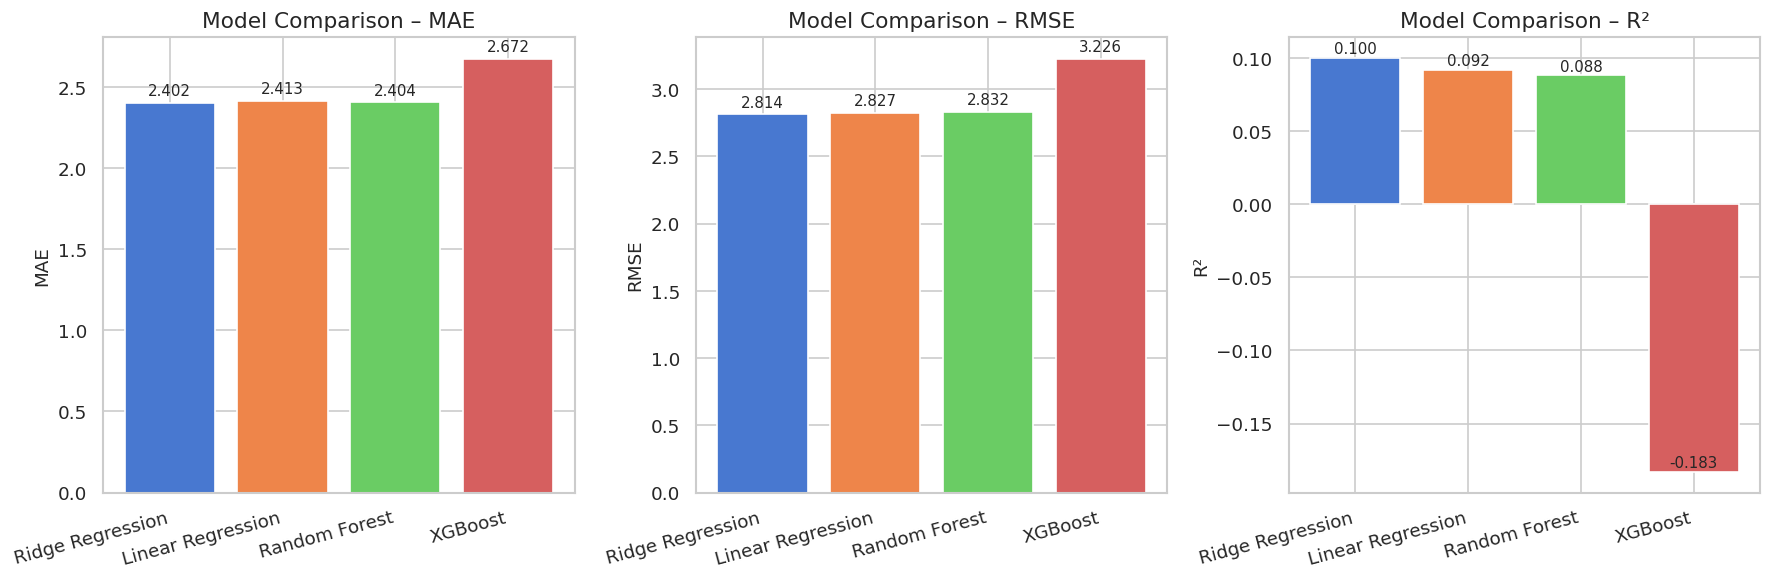

In [15]:
# ── Bar chart: MAE & RMSE comparison ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = metrics_df['Model']
colors = sns.color_palette("muted", len(model_names))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = metrics_df[metric]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white')
    ax.set_title(f'Model Comparison – {metric}')
    ax.set_ylabel(metric)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals) * 0.01),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()


Best model: Ridge Regression  |  R²=0.1  |  MAE=2.402  |  RMSE=2.814


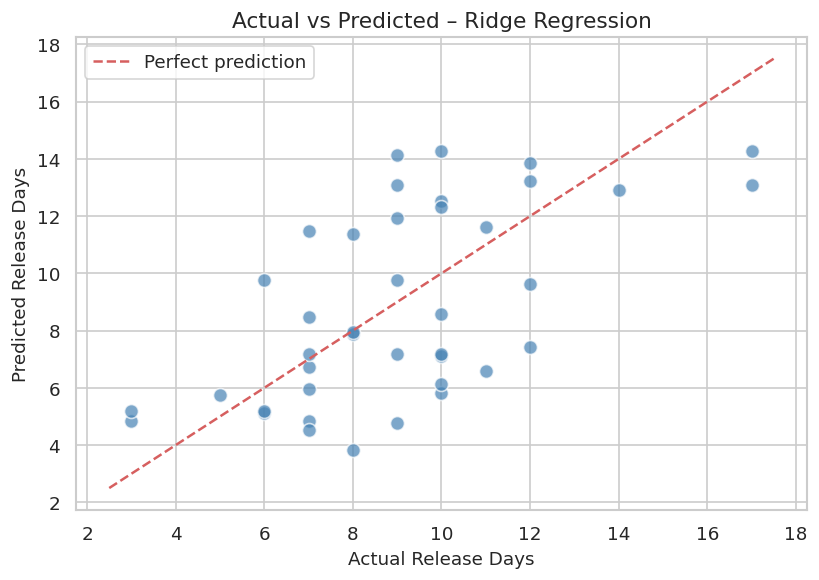

In [16]:
# ── Actual vs Predicted for best model ──
# Identify best model by R²
best = max(results, key=lambda r: r['R²'])
print(f"Best model: {best['Model']}  |  R²={best['R²']}  |  MAE={best['MAE']}  |  RMSE={best['RMSE']}")

preds = best['_preds']
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, preds, alpha=0.7, color='steelblue', edgecolors='white', s=70)
lims = [min(y_test.min(), preds.min()) - 0.5, max(y_test.max(), preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Release Days')
ax.set_ylabel('Predicted Release Days')
ax.set_title(f'Actual vs Predicted – {best["Model"]}')
ax.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


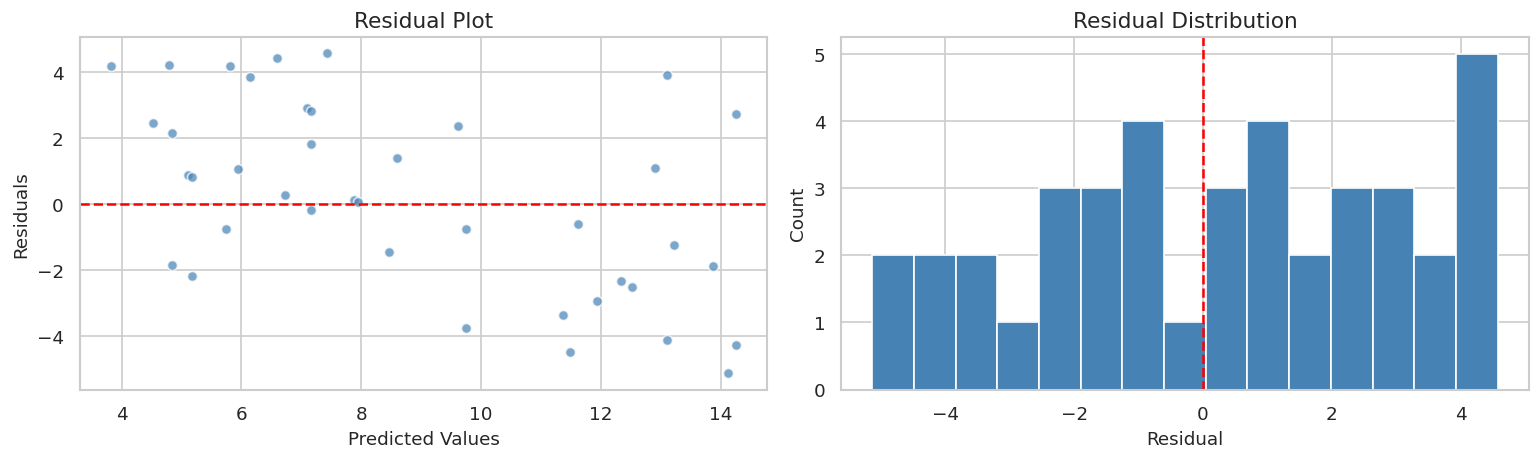

Mean residual: 0.2141  |  Std: 2.8059


In [17]:
# ── Residual plot ──
residuals = y_test.values - preds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(preds, residuals, alpha=0.7, color='steelblue', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('plot_residuals.png', bbox_inches='tight')
plt.show()
print(f"Mean residual: {residuals.mean():.4f}  |  Std: {residuals.std():.4f}")


---
<a id='6'></a>
## 6. Feature Importance

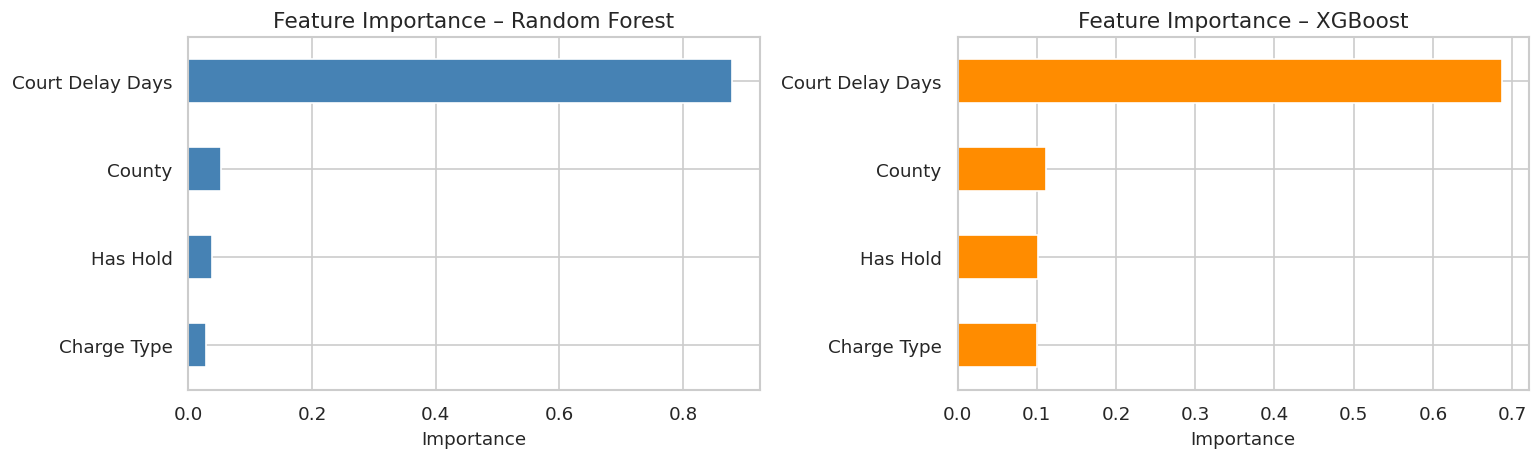

In [18]:
# Use Random Forest and XGBoost feature importances
rf_model  = next(r['_model'] for r in results if r['Model'] == 'Random Forest')
xgb_model = next(r['_model'] for r in results if r['Model'] == 'XGBoost')

feature_labels = ['Court Delay Days', 'Has Hold', 'Charge Type', 'County']

fi_rf  = pd.Series(rf_model.feature_importances_,  index=feature_labels).sort_values(ascending=True)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=feature_labels).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fi_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importance – Random Forest')
axes[0].set_xlabel('Importance')

fi_xgb.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Feature Importance – XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()


---
### 6b. Inference: Predicting for a New Booking

In [19]:
# ── Predict release days for a hypothetical new booking ──
new_booking = pd.DataFrame({
    'court_delay_days': [3],
    'holds':            [1],
    'charge_type_enc':  [le_charge.transform(['Felony'])[0]],
    'county_enc':       [le_county.transform(['Jefferson'])[0]]
})

best_model = best['_model']
prediction = best_model.predict(new_booking)[0]

print("── New Booking Details ──────────────────────")
print("  Charge Type   : Felony")
print("  County        : Jefferson")
print("  Court Delay   : 3 days")
print("  Has Hold      : Yes")
print("─────────────────────────────────────────────")
print(f"  Predicted Release Days: {prediction:.1f} days")


── New Booking Details ──────────────────────
  Charge Type   : Felony
  County        : Jefferson
  Court Delay   : 3 days
  Has Hold      : Yes
─────────────────────────────────────────────
  Predicted Release Days: 19.5 days


---
<a id='7'></a>
## 7. Conclusions & Key Findings

### Model Performance
The best-performing model was evaluated on a held-out 20% test set. All four models were compared using MAE, RMSE, and R² metrics along with 5-fold cross-validation.

### Key Insights from EDA
- **Boone County** has the longest average release time among the four counties.
- **Court delay** is positively correlated with release duration — longer court scheduling delays lead to longer stays.
- Inmates with **active holds** tend to have slightly longer detention periods.
- **Felonies** generally result in longer stays than misdemeanors.

### Feature Importance
Across both Random Forest and XGBoost, `court_delay_days` and `holds` consistently emerge as the strongest predictors of release duration.

### Limitations & Future Work
- The dataset contains only 200 records — a larger dataset would significantly improve model reliability.
- Additional features (e.g., bail amount, prior record, attorney status) could improve predictive power.
- A classification version (Short / Medium / Long stay) could be useful for resource planning.
- Time-series modeling could forecast future jail population loads by county.

---
*Project by Esther | GitHub Portfolio | 2024*
